# Data inspection

In [21]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os

sys.path.append("/home/johmathe/bgbench")
os.environ["PYTHONPATH"] = os.pathsep.join(sys.path)
from src.data import omics_datamodule


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


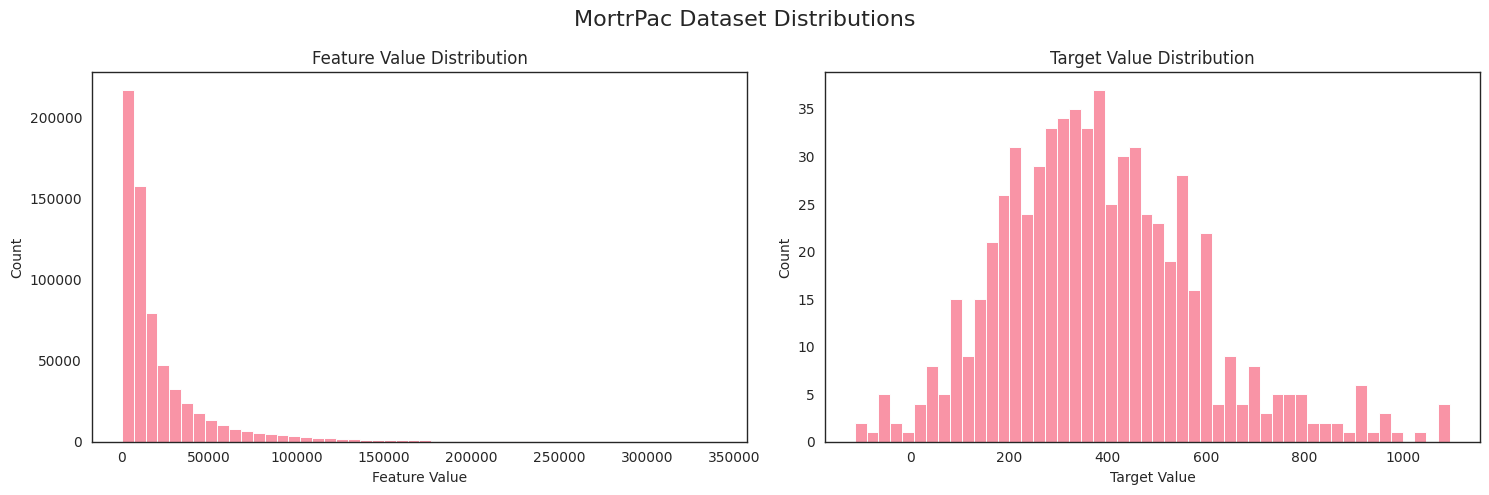


MortrPac Dataset Statistics:
Number of samples: 654
Number of features: 1000

Target Statistics:
Mean: 383.33
Std: 202.67
Min: -113.80
Max: 1097.00


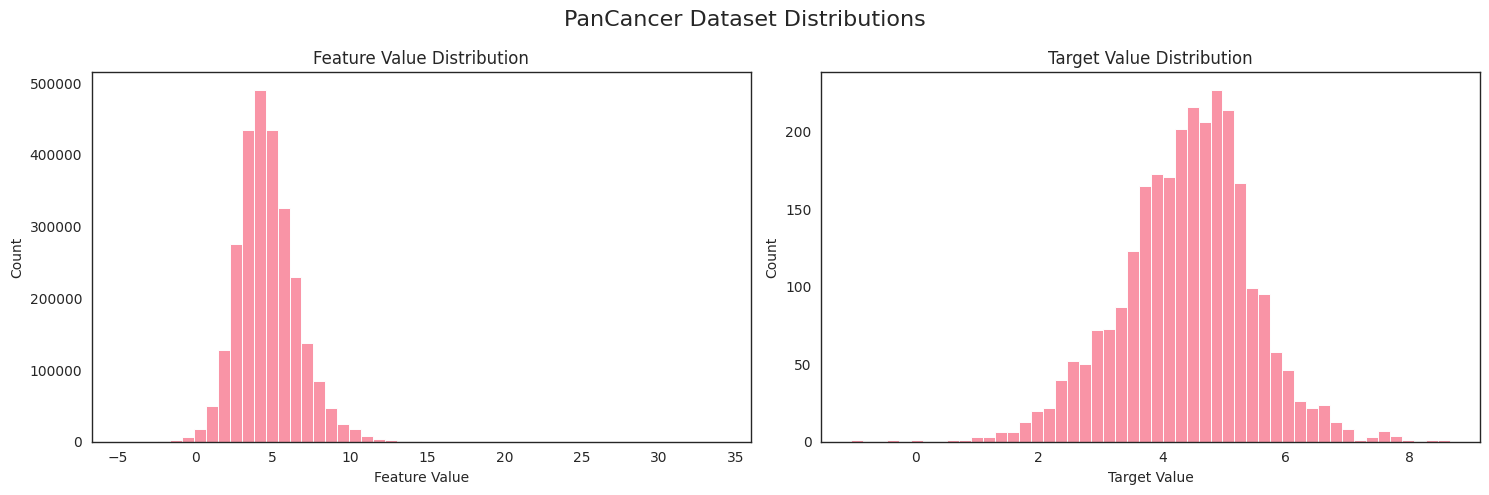


PanCancer Dataset Statistics:
Number of samples: 2725
Number of features: 1000

Target Statistics:
Mean: 4.39
Std: 1.06
Min: -1.04
Max: 8.66


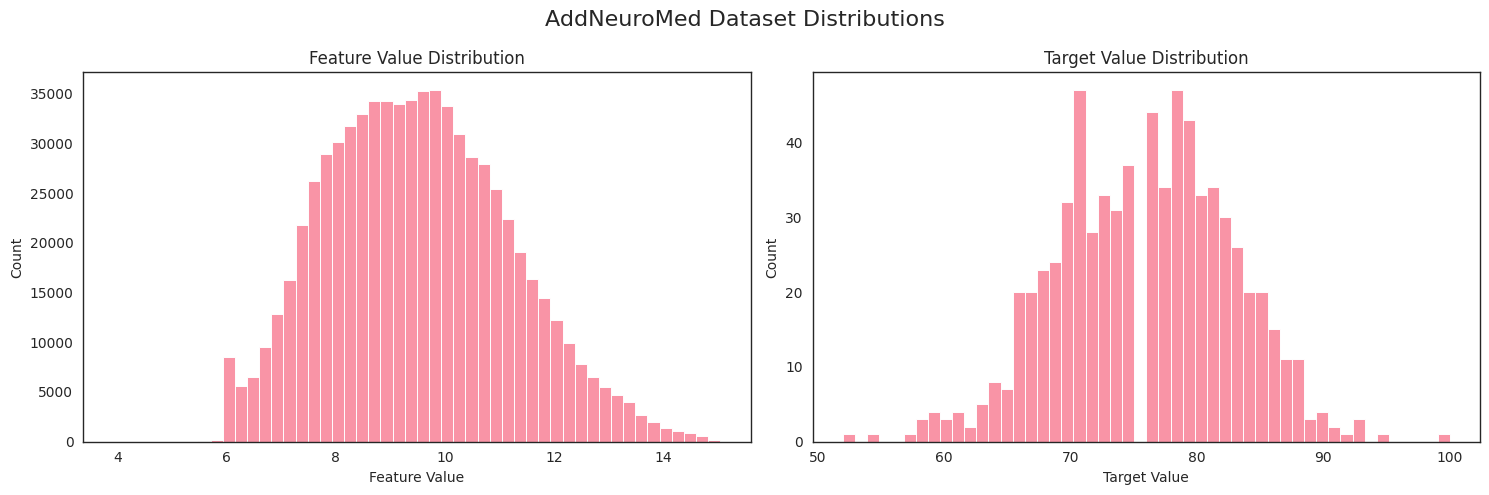


AddNeuroMed Dataset Statistics:
Number of samples: 717
Number of features: 1000

Target Statistics:
Mean: 75.82
Std: 6.82
Min: 52.00
Max: 100.00


In [24]:

# Set style
sns.set_palette("husl")

def plot_dataset_distributions(datamodule_class, title):
    """Plot feature and target distributions for a dataset."""
    # Initialize datamodule
    datamodule = datamodule_class()
    datamodule.prepare_data()
    
    # Load data
    selected_data = pd.read_parquet(datamodule.selected_data_path)
    targets = np.load(datamodule.targets_path)
    
    # Create figure
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    fig.suptitle(f'{title} Dataset Distributions', fontsize=16)
    
    # Plot feature distributions
    sns.histplot(data=selected_data.values.flatten(), ax=ax1, bins=50)
    ax1.set_title('Feature Value Distribution')
    ax1.set_xlabel('Feature Value')
    ax1.set_ylabel('Count')
    
    # Plot target distribution
    sns.histplot(data=targets, ax=ax2, bins=50)
    ax2.set_title('Target Value Distribution')
    ax2.set_xlabel('Target Value')
    ax2.set_ylabel('Count')
    
    plt.tight_layout()
    plt.show()
    
    # Print statistics
    print(f"\n{title} Dataset Statistics:")
    print(f"Number of samples: {len(targets)}")
    print(f"Number of features: {selected_data.shape[1]}")
    print(f"\nTarget Statistics:")
    print(f"Mean: {np.mean(targets):.2f}")
    print(f"Std: {np.std(targets):.2f}")
    print(f"Min: {np.min(targets):.2f}")
    print(f"Max: {np.max(targets):.2f}")

# Plot distributions for each dataset
plot_dataset_distributions(omics_datamodule.MortrPacDataModule, "MortrPac")
plot_dataset_distributions(omics_datamodule.PanCancerDataModule, "PanCancer")
plot_dataset_distributions(omics_datamodule.AddNeuroMedOmicsDataModule, "AddNeuroMed")